In [2]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os

data_type = 'float32'

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pickle

import tqdm
from tqdm import tqdm

import xgboost
from xgboost import XGBClassifier


merged_features = pd.read_csv('../Leydig_info_0.02_vif_10.csv', index_col=0)

In [3]:
y = merged_features['age']
features = list(merged_features.columns)
features.remove('age')
X = merged_features[features]

In [4]:
cont_ftrs = features

    # standard scaler for continuous feature
numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())])

preprocess = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, cont_ftrs)])

In [5]:
param_grid = {"learning_rate": [0.05],
              "n_estimators": [8000],
              "subsample": [0.66],
              "objective": ['multi:softmax'],
              "colsample_bytree": [0.8],
              "eval_metric": ['mlogloss']}



max_depth = [3, 4, 5, 6, 7, 10]

train_scores = []
test_scores = []
cv_scores = []
max_depths = []

best_max = []
best_test = []

for i in tqdm(range(5)):
    train_scores_tmp = []
    test_scores_tmp = []
    cv_scores_tmp = []
    max_depths_tmp = []
    
    random_state = 42*i
    param_grid['seed'] = [random_state]
    # split the data to other and test (80-20)
    X_other, X_test, y_other, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=random_state)
   
   
    kfold = KFold(n_splits=5, shuffle=True, random_state=random_state)
    X_test0 = pd.DataFrame(X_test)
    
    for train_idx, cv_idx in kfold.split(X_other): 
        X_train, X_cv = X_other.iloc[train_idx], X_other.iloc[cv_idx]
        y_train, y_cv = y_other.iloc[train_idx], y_other.iloc[cv_idx]
        
        X_train = preprocess.fit_transform(X_train)

        X_test = preprocess.transform(X_test0)
        X_cv = preprocess.transform(X_cv)
    
        for j in max_depth:
            param_grid['max_depth'] = [j]
            XGB = XGBClassifier()
            XGB.set_params(**ParameterGrid(param_grid)[0])
            XGB.fit(X_train,y_train,early_stopping_rounds=50,eval_set=[(X_cv, y_cv)], verbose=False)

            y_train_pred = XGB.predict(X_train)
            y_test_pred = XGB.predict(X_test)
            y_cv_pred = XGB.predict(X_cv)
            # Accumulate the training and validation scores into tmp arrays, 
            train_scores_tmp.append(accuracy_score(y_train,y_train_pred))
            test_scores_tmp.append(accuracy_score(y_test,y_test_pred))
            cv_scores_tmp.append(accuracy_score(y_cv,y_cv_pred))
            max_depths_tmp.append(j)
    
    # Accumulate the training and validation scores into arrays
    train_scores = train_scores + train_scores_tmp
    cv_scores = cv_scores + cv_scores_tmp
    
    test_scores = test_scores + test_scores_tmp
    max_depths = max_depths + max_depths_tmp
    
    
    
    # print out the best test score and the best max depth value
    print('\nrandom state: ', random_state)
    
    best_max.append(max_depths_tmp[np.argmax(cv_scores_tmp)])
    best_test.append(test_scores_tmp[np.argmax(cv_scores_tmp)])
    
    print('the best validation score: ', max(cv_scores_tmp), 
          ' when max depth = ', best_max[i],
         'with test score: ', best_test[i])

 20%|████████████████                                                                | 1/5 [31:32<2:06:11, 1892.93s/it]


random state:  0
the best validation score:  0.8261163734776725  when max depth =  6 with test score:  0.8035714285714286


 40%|███████████████████████████████▏                                              | 2/5 [1:07:03<1:41:38, 2032.73s/it]


random state:  42
the best validation score:  0.8275862068965517  when max depth =  6 with test score:  0.8235930735930735


 60%|██████████████████████████████████████████████▊                               | 3/5 [1:41:28<1:08:14, 2047.31s/it]


random state:  84
the best validation score:  0.835023664638269  when max depth =  4 with test score:  0.8127705627705628


 80%|████████████████████████████████████████████████████████████████                | 4/5 [2:12:06<32:44, 1964.92s/it]


random state:  126
the best validation score:  0.8220568335588633  when max depth =  5 with test score:  0.8198051948051948


100%|████████████████████████████████████████████████████████████████████████████████| 5/5 [2:43:15<00:00, 1959.10s/it]


random state:  168
the best validation score:  0.8289384719405003  when max depth =  6 with test score:  0.8068181818181818


In [6]:
# fit transform the features once, and store it
feature_names = cont_ftrs

mean_train: [0.99955357 1.         1.         1.         1.         1.        ] 
std_train: [0.00069623 0.         0.         0.         0.         0.        ]
mean_val: [0.80798082 0.81114605 0.81160633 0.81182311 0.81163296 0.80638399] 
std_val: [0.01023366 0.0110212  0.01096262 0.01079329 0.01081363 0.01203731]


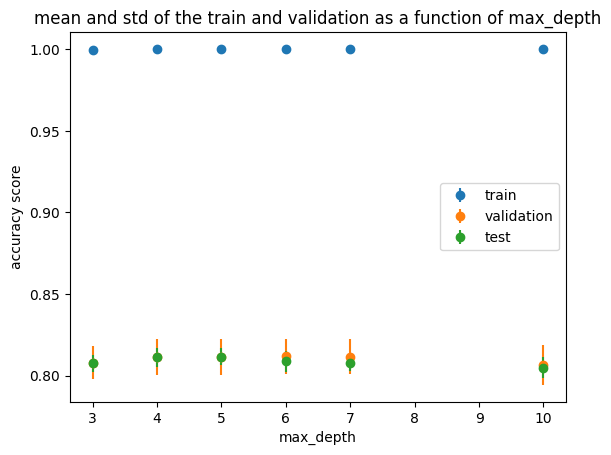

In [7]:
import matplotlib.pyplot as plt

depth = len(max_depth)

mean_train = np.zeros(depth)
std_train = np.zeros(depth)

mean_test = np.zeros(depth)
std_test = np.zeros(depth)

mean_cv = np.zeros(depth)
std_cv = np.zeros(depth)

train_scores = np.array(train_scores)
cv_scores = np.array(cv_scores)
test_scores = np.array(test_scores)
max_depths = np.array(max_depths)

for i in range(depth):
    mean_train[i] = np.mean(train_scores[max_depths == max_depth[i]])
    std_train[i] = np.std(train_scores[max_depths == max_depth[i]])
    
    mean_test[i] = np.mean(test_scores[max_depths == max_depth[i]])
    std_test[i] = np.std(test_scores[max_depths == max_depth[i]])

    mean_cv[i] = np.mean(cv_scores[max_depths == max_depth[i]])
    std_cv[i] = np.std(cv_scores[max_depths == max_depth[i]])
    
print('mean_train:', mean_train, '\nstd_train:', std_train)
print('mean_val:', mean_cv, '\nstd_val:', std_cv)

plt.errorbar(max_depth, mean_train, yerr=std_train, fmt='o', label='train')
plt.errorbar(max_depth, mean_cv, yerr=std_cv, fmt='o', label='validation')
plt.errorbar(max_depth, mean_test, yerr=std_test, fmt='o', label='test')

#plt.semilogx()
plt.title('mean and std of the train and validation as a function of max_depth')
plt.ylabel('accuracy score')
plt.xlabel('max_depth')
plt.legend()
plt.show()

In [8]:
param_grid = {"learning_rate": [0.05],
              "n_estimators": [8000],
              "subsample": [0.66],
              "objective": ['multi:softmax'],
              "max_depth":[6],
              "eval_metric": ['mlogloss']}


models = []
best_test = []
test_sets = []

for i in tqdm(range(10)):
    test_scores_tmp = []
    cv_scores_tmp = []
    models_tmp = []
    test_sets_temp = []
    
    random_state = 42*i
    param_grid['seed'] = [random_state]
    # split the data to other and test (80-20)
    X_other, X_test, y_other, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=random_state)
    # Since the data is not group based, 
    # use KFold with 4 folds: 3/4 of the data points for training and
    # 1/4 of the data points for cross validation
   
    kfold = KFold(n_splits=5, shuffle=True, random_state=random_state)
    X_test0 = pd.DataFrame(X_test)
    
    for train_idx, cv_idx in kfold.split(X_other): 
        X_train, X_cv = X_other.iloc[train_idx], X_other.iloc[cv_idx]
        y_train, y_cv = y_other.iloc[train_idx], y_other.iloc[cv_idx]
        
        X_train = preprocess.fit_transform(X_train)
        df_train = pd.DataFrame(data=X_train,columns = feature_names)

        X_cv = preprocess.transform(X_cv)
        df_cv = pd.DataFrame(data=X_cv, columns = feature_names)
        
        X_test = preprocess.transform(X_test0)
        df_test = pd.DataFrame(data=X_test,columns = feature_names)

        
        XGB = XGBClassifier()
        XGB.set_params(**ParameterGrid(param_grid)[0])
        XGB.fit(df_train,y_train,early_stopping_rounds=50,eval_set=[(df_cv, y_cv)], verbose=False)

        y_test_pred = XGB.predict(df_test)
        y_cv_pred = XGB.predict(df_cv)
        
        # Accumulate the training and validation scores into tmp arrays, 
        test_scores_tmp.append(accuracy_score(y_test,y_test_pred))
        cv_scores_tmp.append(accuracy_score(y_cv,y_cv_pred))
        models_tmp.append(XGB)
        test_sets_temp.append((df_test, y_test))
        
    # Accumulate the training and validation scores into arrays
    best_test.append(test_scores_tmp[np.argmax(cv_scores_tmp)])
    models.append(models_tmp[np.argmax(cv_scores_tmp)])
    test_sets.append(test_sets_temp[np.argmax(cv_scores_tmp)])
    # print out the best test score and the best max depth value
    print('\nrandom state: ', random_state)

    print('the best validation score: ', max(cv_scores_tmp),
         'with test score: ', best_test[i])

 10%|████████                                                                        | 1/10 [07:09<1:04:24, 429.42s/it]


random state:  0
the best validation score:  0.8194726166328601 with test score:  0.8143939393939394


 20%|████████████████▍                                                                 | 2/10 [14:26<57:50, 433.77s/it]


random state:  42
the best validation score:  0.828262339418526 with test score:  0.8208874458874459


 30%|████████████████████████▌                                                         | 3/10 [21:11<49:05, 420.72s/it]


random state:  84
the best validation score:  0.8397565922920892 with test score:  0.8116883116883117


 40%|████████████████████████████████▊                                                 | 4/10 [27:50<41:13, 412.21s/it]


random state:  126
the best validation score:  0.8227334235453315 with test score:  0.8187229437229437


 50%|█████████████████████████████████████████                                         | 5/10 [34:39<34:15, 411.09s/it]


random state:  168
the best validation score:  0.8235294117647058 with test score:  0.8116883116883117


 60%|█████████████████████████████████████████████████▏                                | 6/10 [41:09<26:55, 403.85s/it]


random state:  210
the best validation score:  0.8227334235453315 with test score:  0.8192640692640693


 70%|█████████████████████████████████████████████████████████▍                        | 7/10 [48:00<20:18, 406.06s/it]


random state:  252
the best validation score:  0.8255578093306288 with test score:  0.8192640692640693


 80%|█████████████████████████████████████████████████████████████████▌                | 8/10 [54:45<13:31, 405.86s/it]


random state:  294
the best validation score:  0.828262339418526 with test score:  0.8165584415584416


 90%|████████████████████████████████████████████████████████████████████████        | 9/10 [1:01:09<06:39, 399.00s/it]


random state:  336
the best validation score:  0.8242055442866801 with test score:  0.8170995670995671


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [1:07:41<00:00, 406.17s/it]


random state:  378
the best validation score:  0.828262339418526 with test score:  0.8111471861471862


In [9]:
file = open('../Leydig_info_0.02_vif_10_final.save', 'wb')
pickle.dump(models, file)
file.close()

file = open('../Leydig_info_0.02_vif_10_final_test_score.save', 'wb')
pickle.dump(best_test, file)
file.close()

file = open('../Leydig_info_0.02_vif_10_final_test_sets.save', 'wb')
pickle.dump((test_sets),file)
file.close()

# fit transform the features once, and store it
feature_names = cont_ftrs

file = open('../Leydig_info_0.02_vif_10_final_feature_names.save', 'wb')
pickle.dump((feature_names),file)
file.close()

In [10]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import os

data_type = 'float32'

import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

# silence scanpy that prints a lot of warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, KFold, train_test_split, ParameterGrid
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import pickle

import tqdm
from tqdm import tqdm

import xgboost
from xgboost import XGBClassifier

In [11]:
file = open('../Leydig_info_0.02_vif_10_final.save', 'rb')
xgbt = pickle.load(file)
file.close()

file = open('../Leydig_info_0.02_vif_10_final_test_sets.save', 'rb')
test_sets = pickle.load(file)
file.close()

In [12]:
from statistics import mean, stdev
def get_scores_acc_10(model, baseline=False):
    
    scores = []
    for i in range(0, 10):
        X_test, y_test = test_sets[i]
        
        if baseline:
            scores.append(max(y_test.value_counts())/len(y_test))
        
        else:
            clf = model[i]
            y_pred = clf.predict(X_test)
            scores.append(accuracy_score(y_test, y_pred))
        
        
    print(f'accuracy: {mean(scores)} ± {stdev(scores)}' )

In [13]:
print('baseline scores:') 
get_scores_acc_10(xgbt, baseline=True)

print('\nmodel scores:')
get_scores_acc_10(xgbt)

baseline scores:
accuracy: 0.29967532467532465 ± 0.009186038835729713

model scores:
accuracy: 0.8160714285714286 ± 0.003611559768753294


In [14]:
from sklearn.metrics import confusion_matrix
def get_cm(model, nrun):
    
    aa = 0
    ab = 0
    ac = 0
    ad = 0
    ae = 0
    ba = 0
    bb = 0
    bc = 0
    bd = 0
    be = 0
    ca = 0
    cb = 0
    cc = 0
    cd = 0
    ce = 0
    da = 0
    db = 0
    dc = 0
    dd = 0
    de = 0
    ea = 0
    eb = 0
    ec = 0
    ed = 0
    ee = 0
    
    for i in range(nrun):
        X_test, y_test = test_sets[i]
        
        clf = model[i]
        
        y_pred = clf.predict(X_test)
        
        # calculate the sum of tn, fp, fn, tp to get the mean values to calculate cm
        cm = confusion_matrix(y_test, y_pred)

        aa += cm[0,0]
        ab += cm[0,1]
        ac += cm[0,2]
        ad += cm[0,3]
        ae += cm[0,4]
        aa += cm[1,0]
        bb += cm[1,1]
        bc += cm[1,2]
        bd += cm[1,3]
        be += cm[1,4]
        ca += cm[2,0]
        cb += cm[2,1]
        cc += cm[2,2]
        cd += cm[2,3]
        ce += cm[2,4]
        da += cm[3,0]
        db += cm[3,1]
        dc += cm[3,2]
        dd += cm[3,3]
        de += cm[3,4]
        ea += cm[4,0]
        eb += cm[4,1]
        ec += cm[4,2]
        ed += cm[4,3]
        ee += cm[4,4]
         
    # mean tn, fp, fn, tp --> cm (mean)
    cm = np.array([[aa/nrun, ab/nrun, ac/nrun, ad/nrun, ae/nrun], 
                   [ba/nrun, bb/nrun, bc/nrun, bd/nrun, be/nrun],
                  [ca/nrun, cb/nrun, cc/nrun, cd/nrun, ce/nrun],
                  [da/nrun, db/nrun, dc/nrun, dd/nrun, de/nrun],
                  [ea/nrun, eb/nrun, ec/nrun, ed/nrun, ee/nrun]])
    
    # normalize
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    return cm

def plot_cm(cm, classes):    
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='viridis')
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title='Normalized (mean) confusion matrix(for Xgboost)',
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' 
    thresh = cm.max()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="black" if cm[i, j] == thresh else "white")
    fig.tight_layout()
    return ax

In [15]:
cm = get_cm(xgbt, 10)
cm

array([[4.16666667e-01, 1.14197531e-01, 3.93518519e-01, 6.94444444e-02,
        6.17283951e-03],
       [0.00000000e+00, 8.90676659e-01, 8.55190655e-02, 2.33634560e-02,
        4.40819925e-04],
       [3.70370370e-04, 5.68518519e-02, 8.46481481e-01, 8.27777778e-02,
        1.35185185e-02],
       [7.36512613e-04, 2.98287608e-02, 1.53010495e-01, 7.90278034e-01,
        2.61461978e-02],
       [1.62337662e-03, 1.58279221e-02, 9.09090909e-02, 1.17288961e-01,
        7.74350649e-01]])

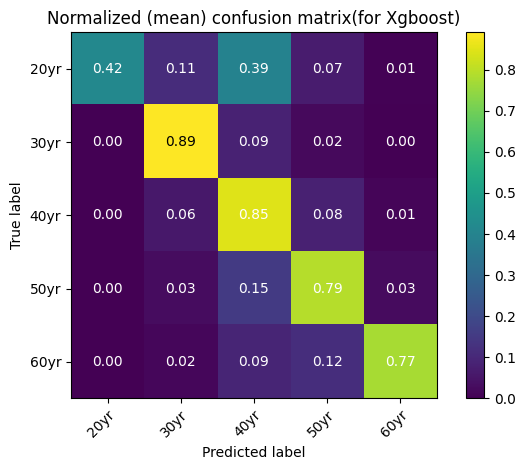

In [16]:
plot_cm(cm, classes=['20yr','30yr', '40yr', '50yr', '60yr'])
plt.savefig('../Leydig_info_0.02_vif_10_final_cm.png')
plt.show()

In [17]:
file = open('../Leydig_info_0.02_vif_10_final_feature_names.save', 'rb')
feature_names = pickle.load(file)
file.close()
feature_names = list(feature_names)

In [18]:
from sklearn.inspection import permutation_importance

np.random.seed(42)
ftr_names = feature_names
nr_runs = 10
scores = np.zeros([len(ftr_names),nr_runs])
X_test5, y_test5 = test_sets[5]
X_test = X_test5
y_test = y_test5
grid = xgbt[5]
# loop through the features

for i in range(len(ftr_names)):
    print('shuffling '+ str(ftr_names[i]))
    
    acc_scores = []
   
    for j in range(nr_runs):
        X_test_shuffled = X_test.copy()
        X_test_shuffled[ftr_names[i]] = np.random.permutation(X_test[ftr_names[i]].values)
        acc_scores.append(grid.score(X_test_shuffled,y_test))
    print('   shuffled test score:',np.around(np.mean(acc_scores),3),'+/-',np.around(np.std(acc_scores),3))
    scores[i] = acc_scores

shuffling MXRA8
   shuffled test score: 0.819 +/- 0.001
shuffling VWA1
   shuffled test score: 0.82 +/- 0.001
shuffling ACTRT2
   shuffled test score: 0.819 +/- 0.0
shuffling FHAD1
   shuffled test score: 0.819 +/- 0.0
shuffling FBLIM1
   shuffled test score: 0.819 +/- 0.001
shuffling PLA2G2A
   shuffled test score: 0.819 +/- 0.0
shuffling PLA2G5
   shuffled test score: 0.819 +/- 0.001
shuffling CAMK2N1
   shuffled test score: 0.818 +/- 0.001
shuffling SH3BGRL3
   shuffled test score: 0.819 +/- 0.002
shuffling ATP5IF1
   shuffled test score: 0.822 +/- 0.001
shuffling MARCKSL1
   shuffled test score: 0.819 +/- 0.001
shuffling TSSK3
   shuffled test score: 0.819 +/- 0.0
shuffling HMGB4
   shuffled test score: 0.819 +/- 0.001
shuffling PTCH2
   shuffled test score: 0.818 +/- 0.001
shuffling P3R3URF
   shuffled test score: 0.819 +/- 0.0
shuffling JUN
   shuffled test score: 0.819 +/- 0.001
shuffling LEPR
   shuffled test score: 0.814 +/- 0.001
shuffling LINC02609
   shuffled test score: 0.

   shuffled test score: 0.82 +/- 0.001
shuffling RIMS2
   shuffled test score: 0.819 +/- 0.001
shuffling DOCK8
   shuffled test score: 0.819 +/- 0.0
shuffling PLIN2
   shuffled test score: 0.82 +/- 0.001
shuffling NDUFB6
   shuffled test score: 0.82 +/- 0.001
shuffling BAG1
   shuffled test score: 0.82 +/- 0.001
shuffling TPM2
   shuffled test score: 0.819 +/- 0.001
shuffling ANXA1
   shuffled test score: 0.82 +/- 0.001
shuffling NTRK2
   shuffled test score: 0.818 +/- 0.001
shuffling ISCA1
   shuffled test score: 0.82 +/- 0.0
shuffling S1PR3
   shuffled test score: 0.819 +/- 0.0
shuffling GADD45G
   shuffled test score: 0.82 +/- 0.0
shuffling PTCH1
   shuffled test score: 0.816 +/- 0.002
shuffling SVEP1
   shuffled test score: 0.819 +/- 0.001
shuffling MUSK
   shuffled test score: 0.819 +/- 0.001
shuffling PTRH1
   shuffled test score: 0.819 +/- 0.0
shuffling ODF2
   shuffled test score: 0.819 +/- 0.001
shuffling IER5L
   shuffled test score: 0.819 +/- 0.001
shuffling LCNL1
   shuffle

   shuffled test score: 0.819 +/- 0.001
shuffling PLTP
   shuffled test score: 0.816 +/- 0.002
shuffling PTGIS
   shuffled test score: 0.819 +/- 0.001
shuffling CEBPB
   shuffled test score: 0.82 +/- 0.001
shuffling ADAMTS1
   shuffled test score: 0.818 +/- 0.002
shuffling ADAMTS5
   shuffled test score: 0.818 +/- 0.001
shuffling PDXK
   shuffled test score: 0.82 +/- 0.0
shuffling TIMP3
   shuffled test score: 0.809 +/- 0.002
shuffling LGALS1
   shuffled test score: 0.819 +/- 0.002
shuffling PRPS2
   shuffled test score: 0.806 +/- 0.002
shuffling SMS
   shuffled test score: 0.819 +/- 0.0
shuffling SAT1
   shuffled test score: 0.82 +/- 0.001
shuffling ARX
   shuffled test score: 0.818 +/- 0.001
shuffling SRPX
   shuffled test score: 0.818 +/- 0.001
shuffling USP11
   shuffled test score: 0.819 +/- 0.001
shuffling PCSK1N
   shuffled test score: 0.819 +/- 0.0
shuffling ITM2A
   shuffled test score: 0.816 +/- 0.002
shuffling TCEAL4
   shuffled test score: 0.819 +/- 0.001
shuffling TCEAL1
 

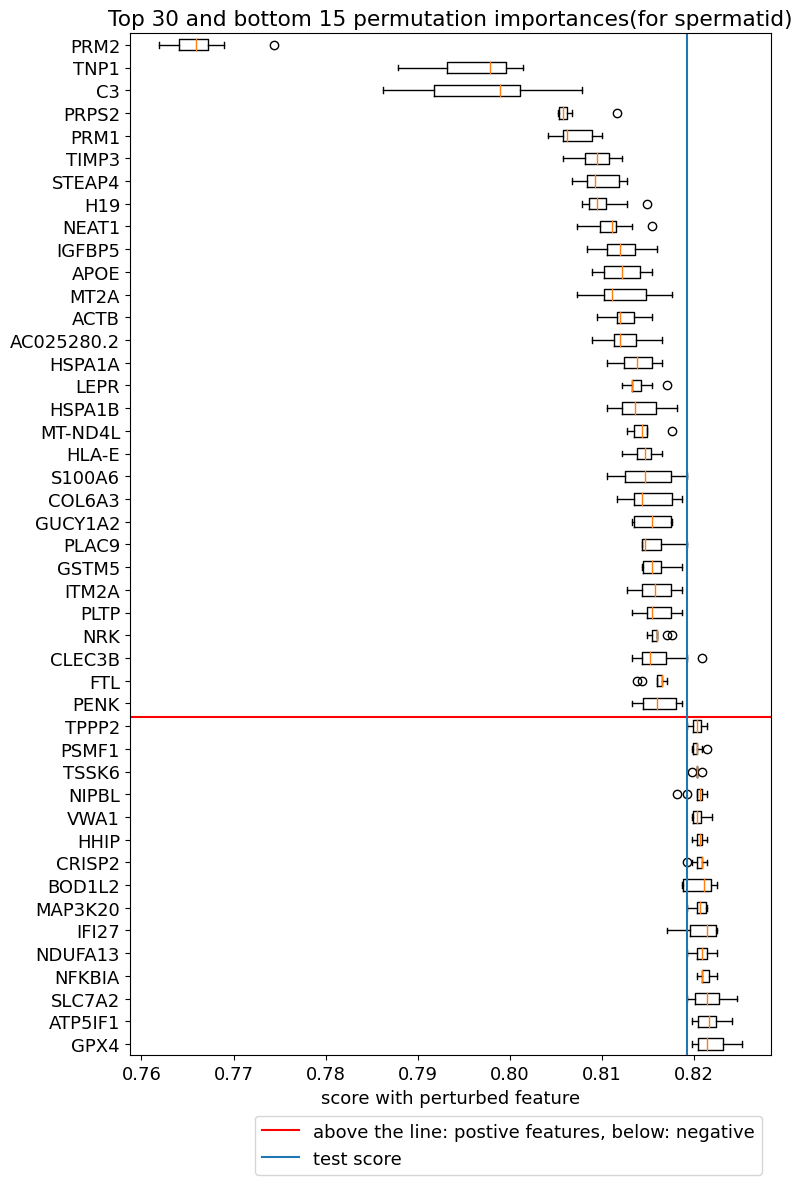

In [19]:
test_score = grid.score(X_test,y_test)

sorted_indcs = np.argsort(np.mean(scores,axis=1))[::-1]

top15 = sorted_indcs[-30:]
low15 = sorted_indcs[:15]
tl15 = np.append(low15, top15)

plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 12))
plt.boxplot(scores[tl15].T,labels=np.array(ftr_names)[tl15],vert=False)
plt.axhline(y= 15.4, color='r', label='above the line: postive features, below: negative')
plt.axvline(test_score, label='test score')
plt.title("Top 30 and bottom 15 permutation importances(for spermatid)")
plt.xlabel('score with perturbed feature')
plt.legend(bbox_to_anchor=(1, -0.05))
plt.tight_layout()
plt.savefig('../Leydig_info_0.02_vif_10_final_permutation_importance.pdf')
plt.show()

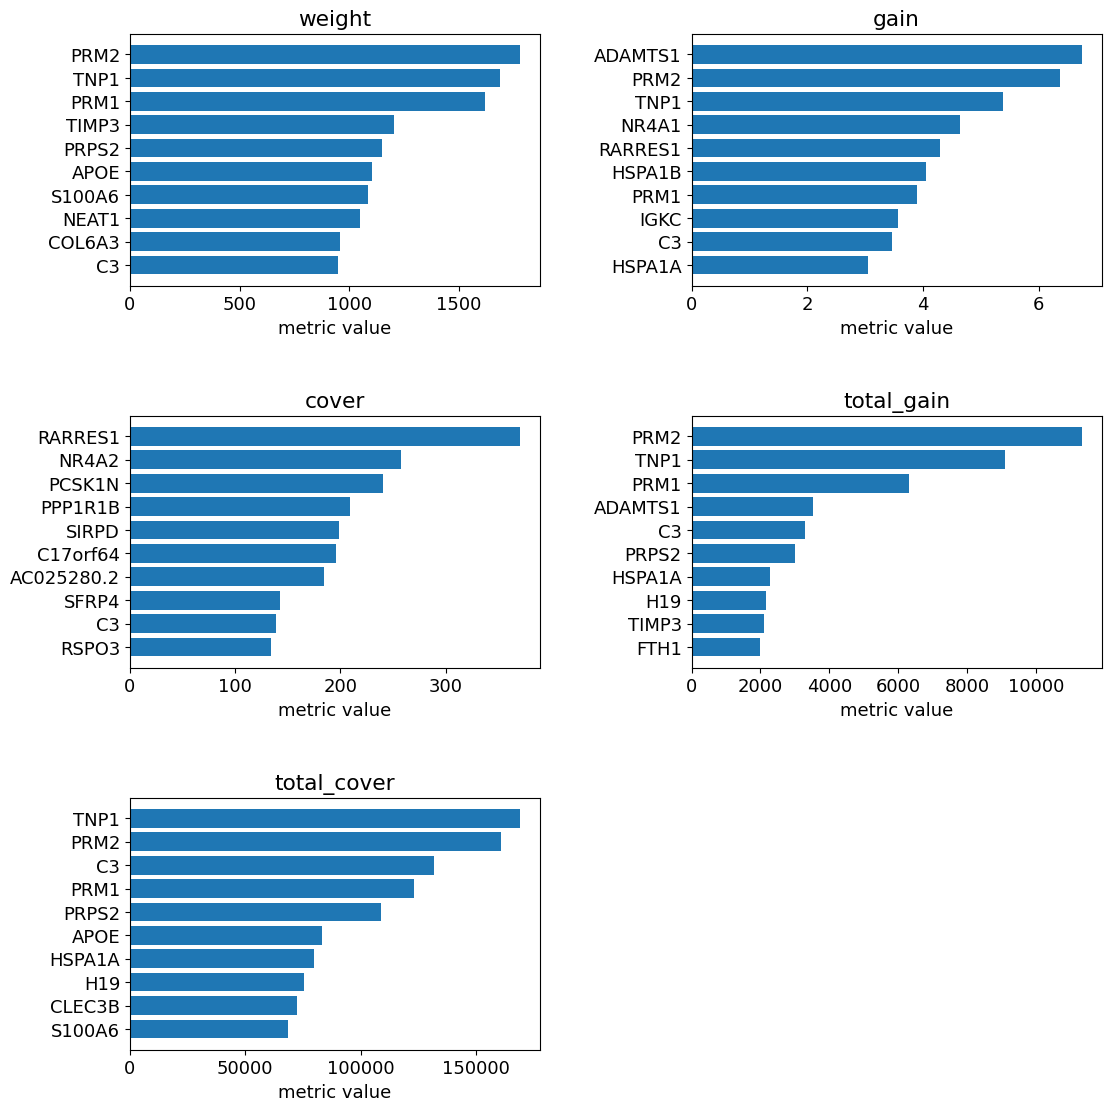

In [20]:
# use the fifth random state
model = xgbt[5]
metrics = ['weight','gain','cover','total_gain','total_cover']

plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(12,12))
for i in range(len(metrics)):
    scores = model.get_booster().get_score(importance_type=metrics[i])
    scores = {k: v for k, v in sorted(scores.items(), key=lambda item: item[1])}
    
    plt.subplot(3, 2, i+1)
    plt.barh(list(scores.keys())[-10:], list(scores.values())[-10:], align='center')
    plt.title(metrics[i])
    plt.xlabel('metric value')
plt.tight_layout(pad=3.0)
plt.savefig('../Leydig_info_0.02_vif_10_final_booster_5_metrics.pdf')
plt.show()

In [21]:
import shap
# https://stackoverflow.com/questions/61928198/getting-unicodedecodeerror-when-using-shap-on-xgboost
booster = model.get_booster() 
model_bytearray = booster.save_raw()[4:]
booster.save_raw = lambda : model_bytearray

shap.initjs() # required for visualizations later on
# create the explainer object with the random forest model
explainer = shap.TreeExplainer(booster)

(5, 1848, 322)


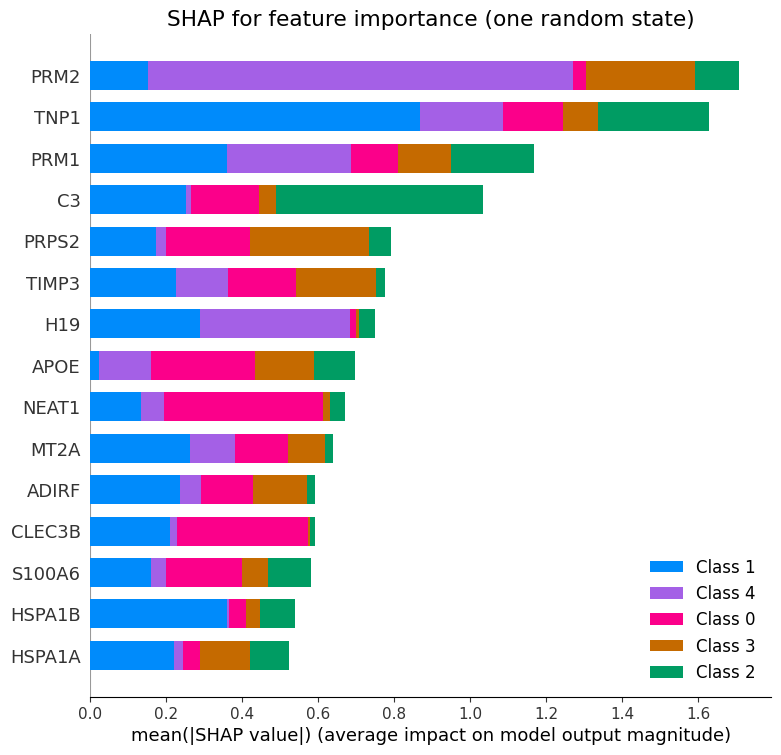

In [22]:
# calculate shap values 
shap_values = explainer.shap_values(X_test5)
print(np.shape(shap_values))

fig = shap.summary_plot(shap_values, X_test5, feature_names = feature_names, max_display=15, show=False)
plt.title('SHAP for feature importance (one random state)')

plt.savefig('../Leydig_info_0.02_vif_10_final_shap.pdf')
plt.show()